# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mfaiqdev/MLinternship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can search and engagement signals be used to identify content items that are plausible candidates for refresh, and can a machine-learning model improve prioritisation compared with a simple rule-based baseline?

### Decision supported

The analysis is designed as a decision-support tool for content teams. It aims to help rank or identify content items that may deserve review, rather than automatically deciding that a page must be refreshed.

The main comparison is between a simple Week 4 baseline rule and the machine-learning approach developed in Weeks 5–6. The goal is to determine whether the additional modelling provides a useful directional signal beyond the baseline.

The analysis focuses on March 2026 data and evaluates the models on a client-grouped holdout set.

In [ ]:
# Basic research-question checks

research_question = (
    "Can search and engagement signals identify plausible content-refresh candidates "
    "and provide useful prioritisation beyond a simple rule-based baseline?"
)

decision_supported = (
    "Prioritise content items for human review; not automatically determine refresh actions."
)

print("Research question:")
print(research_question)
print("\nDecision supported:")
print(decision_supported)

Research question:
Can search and engagement signals identify plausible content-refresh candidates and provide useful prioritisation beyond a simple rule-based baseline?

Decision supported:
Prioritise content items for human review; not automatically determine refresh actions.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data release

This research uses the public-safe FlyRank pseudonymized warehouse release:

`flyrank_pseudonymized_warehouse_release_v20260703`

The analysis was developed primarily from the March 2026 partition of the production-style warehouse data.

### Tables

The warehouse contains four main tables relevant to the project:

- `dim_clients` — 104 client records.
- `dim_content` — 519,606 content records.
- `fact_content_daily_performance` — approximately 78.8 million daily performance rows.
- `fact_content_query_90d` — approximately 2.4 million search-query records.

The main modelling dataset was `fact_content_daily_performance`.

### Analysis window

The modelling analysis uses:

**1 March 2026 – 31 March 2026**

The March partition contained **9,841,378 rows** and **31 columns**.

The analysis found:

- 3,611,061 rows with Google Search Console availability.
- 413,966 rows with Google Analytics 4 availability.
- 55 clients represented in the modelling dataset.
- 331,437 content items represented in the March analysis.

### Exclusions and public-safety choices

The analysis uses pseudonymized identifiers and aggregate performance signals. Client names, private queries, URLs, and other identifying information are not included in the research artifact.

Rows without the signals required for a particular calculation were handled according to the calculation being performed rather than being treated as evidence of poor content performance. For example, missing GA4 sessions were treated as zero when constructing the proxy label because the label definition explicitly used the absence of recorded sessions as part of the operational rule.

The analysis does not attempt to expose or reconstruct individual client identities or private search queries.

In [ ]:
# Public-safe dataset facts used in the capstone

dataset_release = "flyrank_pseudonymized_warehouse_release_v20260703"
analysis_start = "2026-03-01"
analysis_end = "2026-03-31"

dataset_rows = 9_841_378
dataset_columns = 31
gsc_available_rows = 3_611_061
ga4_available_rows = 413_966
client_count = 55
content_count = 331_437

print("Dataset release:", dataset_release)
print("Analysis window:", analysis_start, "to", analysis_end)
print("Rows:", f"{dataset_rows:,}")
print("Columns:", dataset_columns)
print("Clients represented:", f"{client_count:,}")
print("Content items represented:", f"{content_count:,}")
print("Rows with GSC availability:", f"{gsc_available_rows:,}")
print("Rows with GA4 availability:", f"{ga4_available_rows:,}")

Dataset release: flyrank_pseudonymized_warehouse_release_v20260703
Analysis window: 2026-03-01 to 2026-03-31
Rows: 9,841,378
Columns: 31
Clients represented: 55
Content items represented: 331,437
Rows with GSC availability: 3,611,061
Rows with GA4 availability: 413,966


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Assumptions

The analysis treats search visibility, engagement, and page-performance signals as useful indicators for prioritisation. These signals do not prove that a page needs a content refresh.

The target is therefore treated as a **proxy decision label**, not as a ground-truth human refresh decision.

### Week 4 baseline

The baseline is a simple rule:

> `gsc_impressions > 100` AND `gsc_clicks <= 1`

Rows satisfying the rule receive the action:

**Review for Refresh**

The reason code is:

`HIGH_IMPRESSIONS_LOW_CLICKS`

This baseline is intentionally simple and interpretable.

### Proxy label

The modelling proxy label was:

```text
refresh_label =
    (gsc_impressions > 100)
    AND (gsc_clicks <= 1)
    AND (ga4_sessions.fillna(0) == 0)

In [ ]:
# Methodology facts and leakage checks

features = [
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_users",
    "ga4_total_engagement_sec",
    "scroll_events",
]

label_columns = [
    "gsc_impressions",
    "gsc_clicks",
    "ga4_sessions",
]

train_rows = 8_935_676
test_rows = 905_702
train_clients = 44
test_clients = 11
client_overlap = 0

direct_feature_label_overlap = set(features).intersection(label_columns)

print("Features:")
for feature in features:
    print(" -", feature)

print("\nTraining rows:", f"{train_rows:,}")
print("Test rows:", f"{test_rows:,}")
print("Training clients:", train_clients)
print("Test clients:", test_clients)
print("Client overlap:", client_overlap)

print("\nDirect feature/label overlap:", direct_feature_label_overlap)

assert client_overlap == 0
assert len(direct_feature_label_overlap) == 0

print("\nLeakage checks: PASS")

Features:
 - gsc_avg_position
 - ga4_pageviews
 - ga4_users
 - ga4_total_engagement_sec
 - scroll_events

Training rows: 8,935,676
Test rows: 905,702
Training clients: 44
Test clients: 11
Client overlap: 0

Direct feature/label overlap: set()

Leakage checks: PASS


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The models were evaluated against the same client-grouped holdout framework.

| Approach | Precision | Recall | F1 |
|---|---:|---:|---:|
| Week 4 baseline | 0.768 | 1.000 | 0.868 |
| Week 5 Random Forest | 0.309 | 0.693 | 0.428 |
| Week 6 validation Random Forest | 0.122 | 0.974 | 0.217 |

The Week 5 Random Forest did not outperform the Week 4 rule-based baseline.

The Week 6 validation produced substantially higher recall than the Week 5 model, but precision fell further and the F1 score decreased.

The strongest feature in the original Week 5 model was `gsc_avg_position`, with an importance of approximately 0.962. This suggests that search-position information dominated the model's learned signal.

Overall, the modelling results support a cautious conclusion: the machine-learning approach provides a **directional signal for prioritising possible refresh candidates**, but it did not outperform the simple Week 4 baseline on the measured evaluation criteria.

The baseline therefore remains the stronger measured approach for this particular proxy decision task.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Approach": [
        "Week 4 baseline",
        "Week 5 Random Forest",
        "Week 6 validation Random Forest",
    ],
    "Precision": [
        0.7675,
        0.3094,
        0.1218,
    ],
    "Recall": [
        1.0000,
        0.6928,
        0.9735,
    ],
    "F1": [
        0.8685,
        0.4277,
        0.2165,
    ],
})

results

,Approach,Precision,Recall,F1
0,Week 4 baseline,0.7675,1.0000,0.8685
1,Week 5 Random Forest,0.3094,0.6928,0.4277
2,Week 6 validation Random Forest,0.1218,0.9735,0.2165


## 5. Limitations

*What this work cannot claim.*

This analysis has several important limitations.

1. **The target is a proxy label.**  
   The refresh label is derived from search and engagement signals rather than confirmed records of human content-refresh decisions. A positive label therefore means that an item matches the operational definition, not that the content definitely needs a refresh.

2. **The analysis covers one month.**  
   The modelling analysis uses March 2026 data. Results may differ across months, seasons, clients, industries, or changes in search behaviour.

3. **The baseline is intentionally simple.**  
   The Week 4 rule was designed to be transparent and easy to audit. A more sophisticated baseline or additional business rules could produce different results.

4. **The model did not outperform the baseline.**  
   The Random Forest models produced lower F1 scores than the Week 4 baseline. The results therefore do not justify claiming that machine learning is superior for this decision.

5. **The model is a prioritisation signal, not an automated decision-maker.**  
   Search position, impressions, clicks, and engagement signals cannot explain the full reason why content performs poorly. Human review and content-specific context remain necessary.

6. **The validation is client-grouped but not a temporal or causal experiment.**  
   Grouping by client reduces client-level leakage between training and test sets, but the evaluation does not establish that model predictions cause better refresh decisions or improved future performance.

7. **Feature importance is not causal evidence.**  
   The high importance of `gsc_avg_position` indicates that the feature was influential within the fitted model. It does not show that changing search position would cause a change in the refresh outcome.

### Honest framing

The strongest conclusion supported by the analysis is that the available search and engagement signals can provide a **directional decision-support signal for prioritising content for human review**. The evidence does not show that the machine-learning model outperforms the simple rule-based baseline or that the model can automatically determine which content should be refreshed.

In [ ]:
# Limitation checks: keep the final interpretation tied to the measured results.

baseline_f1 = 0.8685
week5_f1 = 0.4277
week6_f1 = 0.2165

print("Baseline F1:", baseline_f1)
print("Week 5 RF F1:", week5_f1)
print("Week 6 validation RF F1:", week6_f1)

assert week5_f1 < baseline_f1
assert week6_f1 < baseline_f1

print("\nConclusion check: neither Random Forest result exceeds the baseline F1.")
print("Honest framing: the model is a directional prioritisation signal, not an automated refresh decision.")

Baseline F1: 0.8685
Week 5 RF F1: 0.4277
Week 6 validation RF F1: 0.2165

Conclusion check: neither Random Forest result exceeds the baseline F1.
Honest framing: the model is a directional prioritisation signal, not an automated refresh decision.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Based on the measured results and the Week 7 action-playbook work, the following recommendations are ranked by practical priority.

### 1. Keep the Week 4 baseline as the primary screening rule

The baseline achieved the strongest measured F1 score (0.8685) while maintaining full recall on the proxy label. It is also simple enough for content teams to understand and audit.

Use the rule:

`gsc_impressions > 100 AND gsc_clicks <= 1`

as a first-pass screening mechanism for identifying pages that deserve review.

### 2. Use machine learning as a secondary prioritisation signal

The Random Forest results did not outperform the baseline, so the model should not replace the rule.

Instead, model outputs can be treated as an additional directional signal when a larger candidate set needs to be prioritised for human review.

### 3. Review search-position context before recommending a refresh

`gsc_avg_position` was the dominant feature in the Week 5 model, with approximately 0.962 feature importance.

This suggests that search-position context deserves particular attention during review. However, feature importance is not causal evidence, so position should be interpreted alongside other performance signals.

### 4. Combine search and engagement evidence

A refresh candidate should not be evaluated using a single metric in isolation. Search visibility, clicks, position, pageviews, users, engagement time, and scrolling behaviour can provide complementary context.

The final decision should remain with a human reviewer who can assess the actual content and search intent.

### 5. Validate the playbook over time before operational adoption

The current analysis is based on March 2026 data and a proxy label. Before using the playbook as an operational system, it should be tested on additional time periods and, ideally, against confirmed refresh outcomes.

### Recommended decision flow

1. Apply the transparent baseline to identify possible candidates.
2. Add model scores or other signals for prioritisation where useful.
3. Inspect search and engagement context.
4. Conduct human content and search-intent review.
5. Record the resulting action.
6. Measure subsequent performance and use confirmed outcomes to improve future validation.

In [ ]:
# Ranked recommendation output

recommendations = [
    "1. Keep the Week 4 baseline as the primary screening rule.",
    "2. Use machine learning as a secondary prioritisation signal.",
    "3. Review search-position context before recommending a refresh.",
    "4. Combine search and engagement evidence.",
    "5. Validate the playbook over time before operational adoption.",
]

for recommendation in recommendations:
    print(recommendation)

1. Keep the Week 4 baseline as the primary screening rule.
2. Use machine learning as a secondary prioritisation signal.
3. Review search-position context before recommending a refresh.
4. Combine search and engagement evidence.
5. Validate the playbook over time before operational adoption.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The main quantitative artifact is the comparison of the Week 4 baseline with the Week 5 and Week 6 Random Forest evaluations.

The table below reports precision, recall, and F1 on the evaluated holdout data.

The charts provide a visual comparison of the same metrics. They are intended to make the main finding easy to inspect: neither Random Forest evaluation exceeded the Week 4 baseline on F1.

The artifacts use aggregate results only and contain no client names, URLs, private queries, or other identifying information.

In [ ]:
import matplotlib.pyplot as plt

# Results table
display(results.round(3))

,Approach,Precision,Recall,F1
0,Week 4 baseline,0.768,1.000,0.868
1,Week 5 Random Forest,0.309,0.693,0.428
2,Week 6 validation Random Forest,0.122,0.974,0.216


### F1 Chart

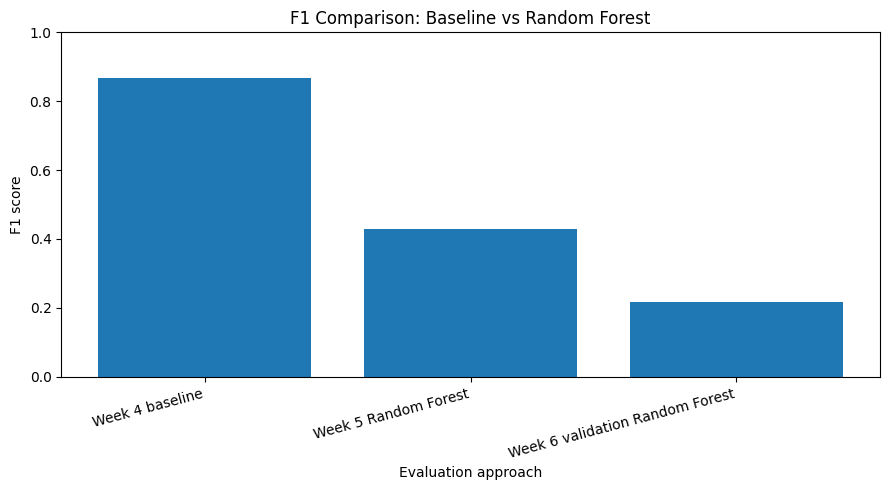

In [ ]:
# F1 comparison

plt.figure(figsize=(9, 5))

plt.bar(results["Approach"], results["F1"])

plt.ylabel("F1 score")
plt.xlabel("Evaluation approach")
plt.title("F1 Comparison: Baseline vs Random Forest")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Precision Chart

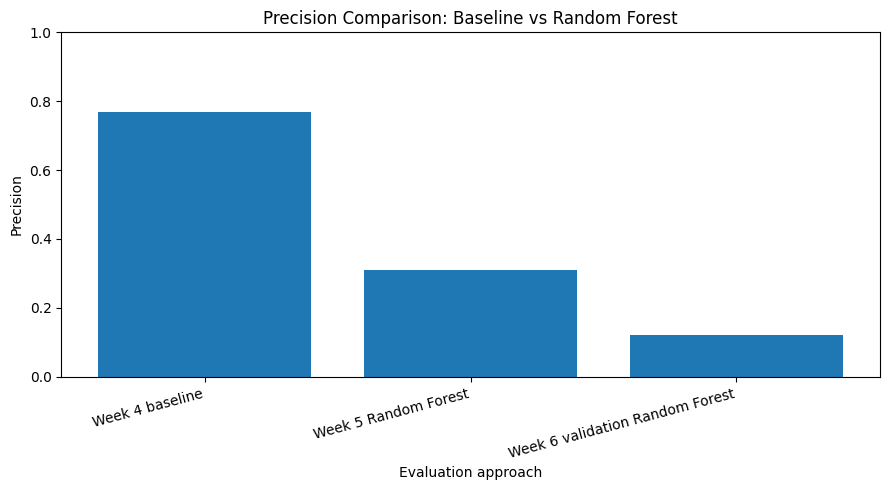

In [ ]:
# Precision comparison

plt.figure(figsize=(9, 5))

plt.bar(results["Approach"], results["Precision"])

plt.ylabel("Precision")
plt.xlabel("Evaluation approach")
plt.title("Precision Comparison: Baseline vs Random Forest")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Recall Chart

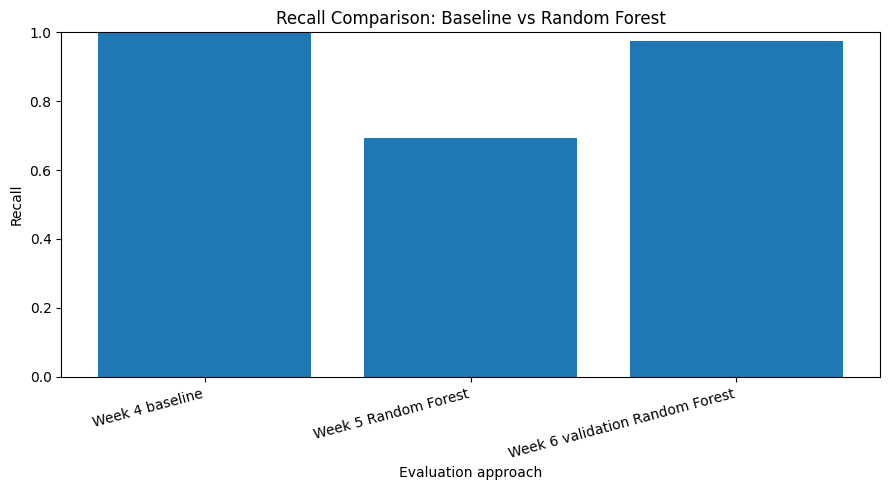

In [ ]:
# Recall comparison

plt.figure(figsize=(9, 5))

plt.bar(results["Approach"], results["Recall"])

plt.ylabel("Recall")
plt.xlabel("Evaluation approach")
plt.title("Recall Comparison: Baseline vs Random Forest")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Artifact interpretation

The charts show the central result of the study.

The Week 4 baseline has the highest F1 score and full recall on the proxy label. Week 5's Random Forest reduces both precision and recall relative to the baseline. Week 6's validation increases recall substantially compared with Week 5, but its precision and F1 fall further.

Therefore, the visual evidence supports retaining the simple baseline as the strongest measured screening approach while treating machine learning as a possible supplementary prioritisation signal rather than a replacement.

## 8. 5-Minute Demo Outline

### Question

**Question:** Can observable search and engagement signals help prioritize content items for possible refresh review, and can a machine-learning model improve prioritization compared with a simple rule-based baseline?

The practical decision is which content items deserve human investigation first when review capacity is limited.

### Method

I used the March 2026 partition of the FlyRank pseudonymized warehouse, containing 9,841,378 rows across 55 clients and 331,437 content items.

I first established a transparent Week-4 baseline using:

`gsc_impressions > 100` AND `gsc_clicks <= 1`

I then evaluated a Random Forest using five independent features: `gsc_avg_position`, `ga4_pageviews`, `ga4_users`, `ga4_total_engagement_sec`, and `scroll_events`.

The evaluation used client-grouped validation so that clients in the training set did not overlap with clients in the test set.

### One Chart

**Chart to show:** the model-versus-baseline Precision, Recall, and F1 comparison.

The chart shows that the Week-4 baseline achieved the strongest measured F1 score, while the Week-6 validation model increased recall but had substantially lower precision.

### One Honest Result

The Week-4 baseline achieved **0.868 F1**, compared with **0.428** for the Week-5 Random Forest and **0.217** for the Week-6 validation Random Forest.

The validation model reached **0.974 recall**, but its precision fell to **0.122**.

Therefore, the evaluated machine-learning approach did **not** outperform the transparent baseline on the measured criteria.

### One Recommendation

Use the simple baseline as the stronger measured starting point for prioritization, while treating machine-learning signals as **directional decision-support for human review** rather than as an autonomous refresh decision.

A practical next step would be to validate the proxy label against real human refresh decisions and future post-refresh outcomes before treating the model as an operational decision system.

## 9. Shareable Cuts

### Social Post

I explored whether search and engagement signals could help prioritize content items for possible refresh review using a public-safe slice of the FlyRank pseudonymized warehouse. I compared a transparent rule-based baseline with a Random Forest model using search-ranking and engagement features, while using client-grouped validation and leakage checks to make the evaluation more reliable. The results showed that the more complex model did not outperform the baseline on F1, reinforcing the value of simple, interpretable signals as a starting point for content prioritization.

### Employer-Facing Summary

I built a content-refresh opportunity scoring workflow that compared a transparent baseline with a Random Forest model using search and engagement signals. I evaluated the approaches on 9,841,378 March 2026 rows from the FlyRank pseudonymized warehouse using client-grouped validation and leakage checks. The model achieved higher recall but lower precision and did not outperform the baseline on F1, leading to an honest framing of the output as directional decision-support for human review.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.